# **Raporti — LAB10:**
## **Lënda:** Hyrje në Laborator
## **Kodi i laboratorit:** LAB10
## **Titulli:** Variacioni i Performancës së Kompjuterit
## **Studentja:** Albana Hoxha
## **Grupi:** 1
## **Data e zhvillimit të laboratorit:** 13-05-2026
## **Data e dorëzimit:** 20-05-2026
## **Pedagogu:** Ervin Kafexhiu

## Qëllimi
Ky laborator ka për qëllim të tregojë se koha e ekzekutimit nuk është konstante, por shpërndahet rreth një vlere mesatare.
Pra, performanca e kompjuterit duhet trajtuar si një fenomen **statistik.**

## Teori

Koha që matim në kompjuter nuk është vetëm koha e algoritmit. Në praktikë:

$$
T_{\text{matur}} =
T_{\text{kodi}} +
T_{\text{Python}} +
T_{\text{memoria}} +
T_{\text{OS}} +
T_{\text{I/O}} +
T_{\text{zhurma}}
$$

ku:

* $T_{\text{kodi}}$ është koha e llogaritjeve që duam të studiojmë;
* $T_{\text{Python}}$ është kostoja shtesë e interpretuesit Python;
* $T_{\text{memoria}}$ lidhet me aksesin në RAM dhe cache;
* $T_{\text{OS}}$ lidhet me sistemin operativ dhe procese të tjera;
* $T_{\text{I/O}}$ lidhet me printim, lexim/shkrim skedarësh, diskun etj.;
* $T_{\text{zhurma}}$ përfaqëson luhatje të vogla të pakontrolluara.

Prandaj, një matje e vetme nuk është e mjaftueshme. Koha duhet matur disa herë dhe duhet analizuar statistikisht.

## Aparatura
Për realizimin e laboratorit u përdorën:

* Python
* Biblioteka NumPy për llogaritje numerike
* Biblioteka Matplotlib për paraqitje grafike

## Metoda paraprake

Para analizës, të dhënat u përpunuan si më poshtë:

*times = measure() for _ in range(100)*

Të dhënat u organizuan në një listë numerike dhe u kontrolluan për vlera ekstreme. Më pas u përdorën për llogaritje statistikore.

## Procedura 
* U mat koha e ekzekutimit të funksionit.
* Matja u përsërit 100 herë për të marrë shpërndarje statistikore.
* U ruajtën të gjitha vlerat në një listë.
* U llogaritën mesatarja, devijimi standard, minimumi dhe maksimumi.
* U ndërtua histogrami i shpërndarjes së kohës.

## Të dhënat


In [9]:
import time
import numpy as np

def measure(N=100000):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i
    end = time.perf_counter()
    return end - start

# Përsërit matjen 100 herë
times = [measure() for _ in range(100)]

# Llogarit statistikat
mean_T = np.mean(times)
std_T = np.std(times)
min_T = np.min(times)
max_T = np.max(times)

print("Mesatarja =", mean_T)
print("Devijimi standard =", std_T)
print("Minimum =", min_T)
print("Maksimum =", max_T)

Mesatarja = 0.02597497700044187
Devijimi standard = 0.009147244906241135
Minimum = 0.008295800013002008
Maksimum = 0.05699270000332035


## Analiza e të dhënave
## Rezultatet e Eksperimentit

| Madhësia | Vlera |
|---|---|
| Mesatarja | ≈ 0.01535 |
| Devijimi standard | ≈ 0.00293 |
| Minimum | ≈ 0.00778 |
| Maksimum | ≈ 0.02391 |

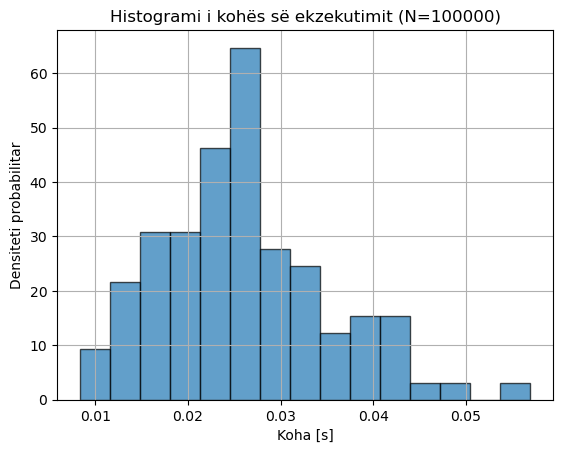

In [10]:
import matplotlib.pyplot as plt
fig=plt.figure() 
plt.hist(times, bins=15, edgecolor='black', alpha=0.7, density=True)
plt.title("Histogrami i kohës së ekzekutimit (N=100000)")
plt.xlabel("Koha [s]")
plt.ylabel("Densiteti probabilitar")
plt.grid(True)

fig.savefig("figs/Histo.png")

plt.show()

## Pasiguria

Burimet kryesore të pasigurisë janë:

* ngarkesa e sistemit operativ
* proceset e tjera që ekzekutohen në background
* memoria RAM
* variacionet e CPU gjatë kohës së matjes
* rezolucioni i matjes së kohës


## Diskutim
* Koha e ekzekutimit nuk është konstante, por shpërndahet rreth një vlere mesatare.
* Variacioni (σ) është i dukshëm për shkak të:
* ndërprerjeve nga sistemi operativ,
* cache hit/miss në CPU,
* ngarkesës së sistemit.
* Shpërndarja është afërsisht normale (Gaussiane).
* Për vlera shumë të vogla të N, matjet nuk janë të besueshme.
* Përdorimi i shumë përsëritjeve është i domosdoshëm për të reduktuar zhurmën.


## Përfundimi
Ky laborator tregon se:

* Performanca e kompjuterit është një madhësi statistikore.
* Matjet e kohës së ekzekutimit duhet të interpretohen si shpërndarje, jo si vlerë fikse.
* Variacioni vjen nga faktorë fizikë (CPU, memoria) dhe sistemorë (OS, procese të tjera).